# 🐧 LAB PS 6 — Statistical Analysis of Physical Characteristics of Palmer Penguins

Complete Google Colab notebook based on the uploaded Lab Problem Statement 6.

**No `%%R` / `rpy2` is used.** R is executed directly through `Rscript` to avoid the previous Colab R-magic problems.

In [1]:
# CELL 1 — Install R and required packages
import subprocess
subprocess.run(["bash","-c","apt-get update -qq && apt-get install -y -qq r-base r-cran-ggplot2 r-cran-dplyr r-cran-e1071 r-cran-car"],check=True)
print("✓ R and required packages installed")

✓ R and required packages installed


In [2]:
# CELL 2 — Download UCI Palmer Penguins dataset
import urllib.request, zipfile, os, glob, shutil
url="https://archive.ics.uci.edu/static/public/690/palmer+penguins.zip"
try:
    urllib.request.urlretrieve(url,"/content/palmer_penguins_uci.zip")
    with zipfile.ZipFile("/content/palmer_penguins_uci.zip") as z:
        z.extractall("/content/uci_penguins")
    csvs=glob.glob("/content/uci_penguins/**/*.csv",recursive=True)
    print("UCI CSV files:",csvs)
    # Prefer the simplified penguins_size file when available
    preferred=[x for x in csvs if "size" in os.path.basename(x).lower()]
    chosen=preferred[0] if preferred else csvs[0]
    shutil.copy(chosen,"/content/penguins.csv")
    print("✓ Dataset selected:",chosen)
except Exception as e:
    print("Direct UCI download unavailable:",e)
    print("R script will use the standard Palmer Penguins package as fallback.")

Direct UCI download unavailable: HTTP Error 404: Not Found
R script will use the standard Palmer Penguins package as fallback.


In [3]:
r_script = '\n# LAB PS 6 - STATISTICAL ANALYSIS OF PALMER PENGUINS\npackages <- c("ggplot2","dplyr","e1071","car")\nfor(p in packages) if(!requireNamespace(p,quietly=TRUE)) install.packages(p,repos="https://cloud.r-project.org")\nlibrary(ggplot2); library(dplyr); library(e1071); library(car)\n\n# Load UCI file if downloaded by Colab; otherwise use standard Palmer Penguins package\nif(file.exists("penguins.csv")) {\n  penguins <- read.csv("penguins.csv",stringsAsFactors=FALSE)\n} else {\n  if(!requireNamespace("palmerpenguins",quietly=TRUE))\n    install.packages("palmerpenguins",repos="https://cloud.r-project.org")\n  penguins <- as.data.frame(palmerpenguins::penguins)\n}\nif("culmen_length_mm"%in%names(penguins)) names(penguins)[names(penguins)=="culmen_length_mm"]<-"bill_length_mm"\nif("culmen_depth_mm"%in%names(penguins)) names(penguins)[names(penguins)=="culmen_depth_mm"]<-"bill_depth_mm"\npenguins$species<-factor(penguins$species); penguins$sex<-factor(penguins$sex)\n\ncat("DATASET:",nrow(penguins),"rows,",ncol(penguins),"columns\\n")\nprint(head(penguins)); cat("\\nMissing values:\\n"); print(colSums(is.na(penguins)))\n\nmass_data<-penguins%>%filter(!is.na(body_mass_g),!is.na(species))\nmass_sex<-penguins%>%filter(!is.na(body_mass_g),!is.na(sex))\nmass_two_way<-penguins%>%filter(!is.na(body_mass_g),!is.na(species),!is.na(sex))\n\n# 1. DESCRIPTIVE STATISTICS\ndescriptive<-mass_data%>%group_by(species)%>%summarise(\n N=n(),Mean=mean(body_mass_g),Median=median(body_mass_g),\n Minimum=min(body_mass_g),Maximum=max(body_mass_g),Variance=var(body_mass_g),\n SD=sd(body_mass_g),Q1=quantile(body_mass_g,.25),Q3=quantile(body_mass_g,.75),\n IQR=IQR(body_mass_g),Skewness=e1071::skewness(body_mass_g,type=2),\n Kurtosis=e1071::kurtosis(body_mass_g,type=2),.groups="drop")\nwrite.csv(descriptive,"descriptive_statistics.csv",row.names=FALSE)\nprint(descriptive)\n\n# Visualizations\nggsave("01_body_mass_histogram.png",ggplot(mass_data,aes(body_mass_g))+geom_histogram(bins=25,fill="steelblue")+\nlabs(title="Histogram of Penguin Body Mass",x="Body Mass (g)",y="Frequency"),width=8,height=5)\nggsave("02_species_body_mass_boxplot.png",ggplot(mass_data,aes(species,body_mass_g,fill=species))+geom_boxplot()+\nlabs(title="Body Mass by Penguin Species",x="Species",y="Body Mass (g)")+theme(legend.position="none"),width=8,height=5)\nggsave("03_body_mass_density.png",ggplot(mass_data,aes(body_mass_g,color=species,fill=species))+geom_density(alpha=.2)+\nlabs(title="Body Mass Density by Species",x="Body Mass (g)",y="Density"),width=8,height=5)\nggsave("04_sex_body_mass_boxplot.png",ggplot(mass_sex,aes(sex,body_mass_g,fill=sex))+geom_boxplot()+\nlabs(title="Body Mass by Sex",x="Sex",y="Body Mass (g)")+theme(legend.position="none"),width=8,height=5)\n\n# 2. MALE VS FEMALE HYPOTHESIS TEST\nmale<-mass_sex$body_mass_g[mass_sex$sex=="male"]; female<-mass_sex$body_mass_g[mass_sex$sex=="female"]\nsh_male<-shapiro.test(male); sh_female<-shapiro.test(female)\npng("05_QQ_male.png",800,600); qqnorm(male,main="QQ Plot - Male Body Mass"); qqline(male); dev.off()\npng("06_QQ_female.png",800,600); qqnorm(female,main="QQ Plot - Female Body Mass"); qqline(female); dev.off()\ntt<-t.test(male,female,var.equal=FALSE)\npooled<-sqrt(((length(male)-1)*var(male)+(length(female)-1)*var(female))/(length(male)+length(female)-2))\nd<-(mean(male)-mean(female))/pooled\ntres<-data.frame(Male_Mean=mean(male),Female_Mean=mean(female),Difference=mean(male)-mean(female),\n T=unname(tt$statistic),DF=unname(tt$parameter),P_Value=tt$p.value,\n CI_Lower=tt$conf.int[1],CI_Upper=tt$conf.int[2],Cohens_d=d)\nwrite.csv(tres,"t_test_results.csv",row.names=FALSE)\nwrite.csv(data.frame(Sex=c("Male","Female"),W=c(sh_male$statistic,sh_female$statistic),\n P_Value=c(sh_male$p.value,sh_female$p.value)),"sex_shapiro_tests.csv",row.names=FALSE)\nprint(tt); print(tres)\n\n# 3. ONE-WAY ANOVA + ASSUMPTIONS + TUKEY\nanova_model<-aov(body_mass_g~species,data=mass_data); anova_table<-as.data.frame(summary(anova_model)[[1]])\nanova_table$Term<-rownames(anova_table); rownames(anova_table)<-NULL\nwrite.csv(anova_table,"one_way_anova_table.csv",row.names=FALSE); print(anova_table)\nspecies_shapiro<-mass_data%>%group_by(species)%>%summarise(W=shapiro.test(body_mass_g)$statistic,\n P_Value=shapiro.test(body_mass_g)$p.value,.groups="drop")\nwrite.csv(species_shapiro,"species_shapiro_tests.csv",row.names=FALSE); print(species_shapiro)\nlev<-car::leveneTest(body_mass_g~species,data=mass_data); write.csv(as.data.frame(lev),"levene_test.csv",row.names=FALSE); print(lev)\npng("07_ANOVA_QQ_plot.png",800,600); qqnorm(residuals(anova_model),main="QQ Plot of ANOVA Residuals"); qqline(residuals(anova_model)); dev.off()\nif(anova_table$`Pr(>F)`[1]<.05){\n  tuk<-TukeyHSD(anova_model); tukdf<-as.data.frame(tuk$species); tukdf$Comparison<-rownames(tukdf); rownames(tukdf)<-NULL\n  write.csv(tukdf,"tukey_hsd_results.csv",row.names=FALSE); print(tuk)\n} else write.csv(data.frame(Note="ANOVA not significant"),"tukey_hsd_results.csv",row.names=FALSE)\n\n# 4. KRUSKAL-WALLIS\nkw<-kruskal.test(body_mass_g~species,data=mass_data)\nwrite.csv(data.frame(Chi_Squared=unname(kw$statistic),DF=unname(kw$parameter),P_Value=kw$p.value),\n"kruskal_wallis_results.csv",row.names=FALSE); print(kw)\n\n# 5. TWO-WAY ANOVA\ntw<-aov(body_mass_g~species*sex,data=mass_two_way); twtab<-as.data.frame(summary(tw)[[1]])\ntwtab$Term<-rownames(twtab); rownames(twtab)<-NULL; write.csv(twtab,"two_way_anova_table.csv",row.names=FALSE); print(twtab)\nggsave("08_species_sex_interaction.png",ggplot(mass_two_way,aes(species,body_mass_g,color=sex,group=sex))+\nstat_summary(fun=mean,geom="point",size=3)+stat_summary(fun=mean,geom="line")+\nlabs(title="Mean Body Mass by Species and Sex",x="Species",y="Mean Body Mass (g)"),width=8,height=5)\n\n# 6. FLIPPER LENGTH\nfl<-penguins%>%filter(!is.na(flipper_length_mm),!is.na(species))\nfa<-aov(flipper_length_mm~species,data=fl); fat<-as.data.frame(summary(fa)[[1]])\nfat$Term<-rownames(fat); rownames(fat)<-NULL; write.csv(fat,"flipper_one_way_anova.csv",row.names=FALSE); print(fat)\nfkw<-kruskal.test(flipper_length_mm~species,data=fl)\nwrite.csv(data.frame(Chi_Squared=unname(fkw$statistic),DF=unname(fkw$parameter),P_Value=fkw$p.value),\n"flipper_kruskal_wallis.csv",row.names=FALSE); print(fkw)\nggsave("09_flipper_length_by_species.png",ggplot(fl,aes(species,flipper_length_mm,fill=species))+geom_boxplot()+\nlabs(title="Flipper Length by Penguin Species",x="Species",y="Flipper Length (mm)")+theme(legend.position="none"),width=8,height=5)\n\nmeans<-mass_data%>%group_by(species)%>%summarise(Mean=mean(body_mass_g),SE=sd(body_mass_g)/sqrt(n()),.groups="drop")\nggsave("10_species_mean_comparison.png",ggplot(means,aes(species,Mean,fill=species))+geom_col()+\ngeom_errorbar(aes(ymin=Mean-SE,ymax=Mean+SE),width=.15)+labs(title="Mean Body Mass by Species (± SE)",x="Species",y="Mean Body Mass (g)")+theme(legend.position="none"),width=8,height=5)\n\n# 7. INTERPRETATION + VALIDATION\npsex<-tt$p.value; panova<-anova_table$`Pr(>F)`[1]; pkw<-kw$p.value; pfl<-fat$`Pr(>F)`[1]\ninterp<-c("STATISTICAL INTERPRETATION",\npaste0("Male-vs-female p-value = ",signif(psex,5),". Sex difference is ",ifelse(psex<.05,"statistically significant.","not statistically significant.")),\npaste0("95% CI for male minus female mean body mass = [",round(tt$conf.int[1],2),", ",round(tt$conf.int[2],2),"] g."),\npaste0("Cohen\'s d = ",round(d,3),"."),\npaste0("One-way ANOVA species p-value = ",signif(panova,5),". Species effect is ",ifelse(panova<.05,"significant.","not significant.")),\npaste0("Kruskal-Wallis p-value = ",signif(pkw,5),"."),\npaste0("Flipper-length ANOVA p-value = ",signif(pfl,5),"."),\n"Conclusion: The workflow combines descriptive statistics, assumption checks, parametric and non-parametric tests, effect size estimation and visualization.")\nwriteLines(interp,"statistical_interpretation.txt"); cat(paste(interp,collapse="\\n"),"\\n")\nvalidation<-data.frame(Check=c("Dataset loaded","Descriptive statistics","t-test","One-way ANOVA","Tukey output","Kruskal-Wallis","Two-way ANOVA","Flipper analysis","Visualizations"),\nResult=c(nrow(penguins)>0,file.exists("descriptive_statistics.csv"),file.exists("t_test_results.csv"),file.exists("one_way_anova_table.csv"),file.exists("tukey_hsd_results.csv"),file.exists("kruskal_wallis_results.csv"),file.exists("two_way_anova_table.csv"),file.exists("flipper_one_way_anova.csv"),file.exists("10_species_mean_comparison.png")))\nwrite.csv(validation,"validation_summary.csv",row.names=FALSE); print(validation)\ncat("LAB PS 6 COMPLETED SUCCESSFULLY\\n")\n'
open('/content/lab_ps6_palmer_penguins.R','w').write(r_script)
print('✓ Complete R script created')

✓ Complete R script created


In [4]:
# CELL 4 — Run complete R analysis
import subprocess
result=subprocess.run(["Rscript","/content/lab_ps6_palmer_penguins.R"],cwd="/content",text=True,capture_output=True)
print(result.stdout)
if result.stderr: print("\n--- R messages/warnings ---\n",result.stderr)
if result.returncode!=0: raise RuntimeError("R analysis failed")
print("✅ LAB PS 6 COMPLETED")

DATASET: 344 rows, 8 columns
  species    island bill_length_mm bill_depth_mm flipper_length_mm body_mass_g
1  Adelie Torgersen           39.1          18.7               181        3750
2  Adelie Torgersen           39.5          17.4               186        3800
3  Adelie Torgersen           40.3          18.0               195        3250
4  Adelie Torgersen             NA            NA                NA          NA
5  Adelie Torgersen           36.7          19.3               193        3450
6  Adelie Torgersen           39.3          20.6               190        3650
     sex year
1   male 2007
2 female 2007
3 female 2007
4   <NA> 2007
5 female 2007
6   male 2007

Missing values:
          species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0 
# A tibble:

In [5]:
# CELL 5 — Display statistical results
import pandas as pd
from IPython.display import display
result_files=["descriptive_statistics.csv","sex_shapiro_tests.csv","t_test_results.csv",
"one_way_anova_table.csv","species_shapiro_tests.csv","levene_test.csv",
"tukey_hsd_results.csv","kruskal_wallis_results.csv","two_way_anova_table.csv",
"flipper_one_way_anova.csv","flipper_kruskal_wallis.csv","validation_summary.csv"]
for f in result_files:
    print("\n================ "+f+" ================")
    display(pd.read_csv("/content/"+f))


================ descriptive_statistics.csv ================


,species,N,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
0,Adelie,151,3700.662252,3700,2850,4775,210282.891832,458.566126,3350.0,4000,650.0,0.285336,-0.573738
1,Chinstrap,68,3733.088235,3700,2700,4800,147713.454785,384.335081,3487.5,3950,462.5,0.247433,0.593379
2,Gentoo,123,5076.016260,5000,3950,6300,254133.180061,504.116237,4700.0,5500,800.0,0.069635,-0.722791



================ sex_shapiro_tests.csv ================


,Sex,W,P_Value
0,Male,0.925043,1.226814e-07
1,Female,0.919314,6.155316e-08



================ t_test_results.csv ================


...

,Df,Sum Sq,Mean Sq,F value,Pr(>F),Term
0,2,52473.283899,26236.641950,594.801627,1.351710e-111,species
1,339,14953.257037,44.109903,NaN,NaN,Residuals



================ flipper_kruskal_wallis.csv ================


,Chi_Squared,DF,P_Value
0,244.890542,2,6.648053e-54



================ validation_summary.csv ================


,Check,Result
0,Dataset loaded,True
1,Descriptive statistics,True
2,t-test,True
3,One-way ANOVA,True
4,Tukey output,True
5,Kruskal-Wallis,True
6,Two-way ANOVA,True
7,Flipper analysis,True
8,Visualizations,True


In [6]:
# CELL 6 — Display interpretation
print(open("/content/statistical_interpretation.txt").read())

STATISTICAL INTERPRETATION
Male-vs-female p-value = 4.7939e-16. Sex difference is statistically significant.
95% CI for male minus female mean body mass = [526.25, 840.58] g.
Cohen's d = 0.936.
One-way ANOVA species p-value = 2.8924e-82. Species effect is significant.
Kruskal-Wallis p-value = 5.6095e-48.
Flipper-length ANOVA p-value = 1.3517e-111.
Conclusion: The workflow combines descriptive statistics, assumption checks, parametric and non-parametric tests, effect size estimation and visualization.




01_body_mass_histogram.png


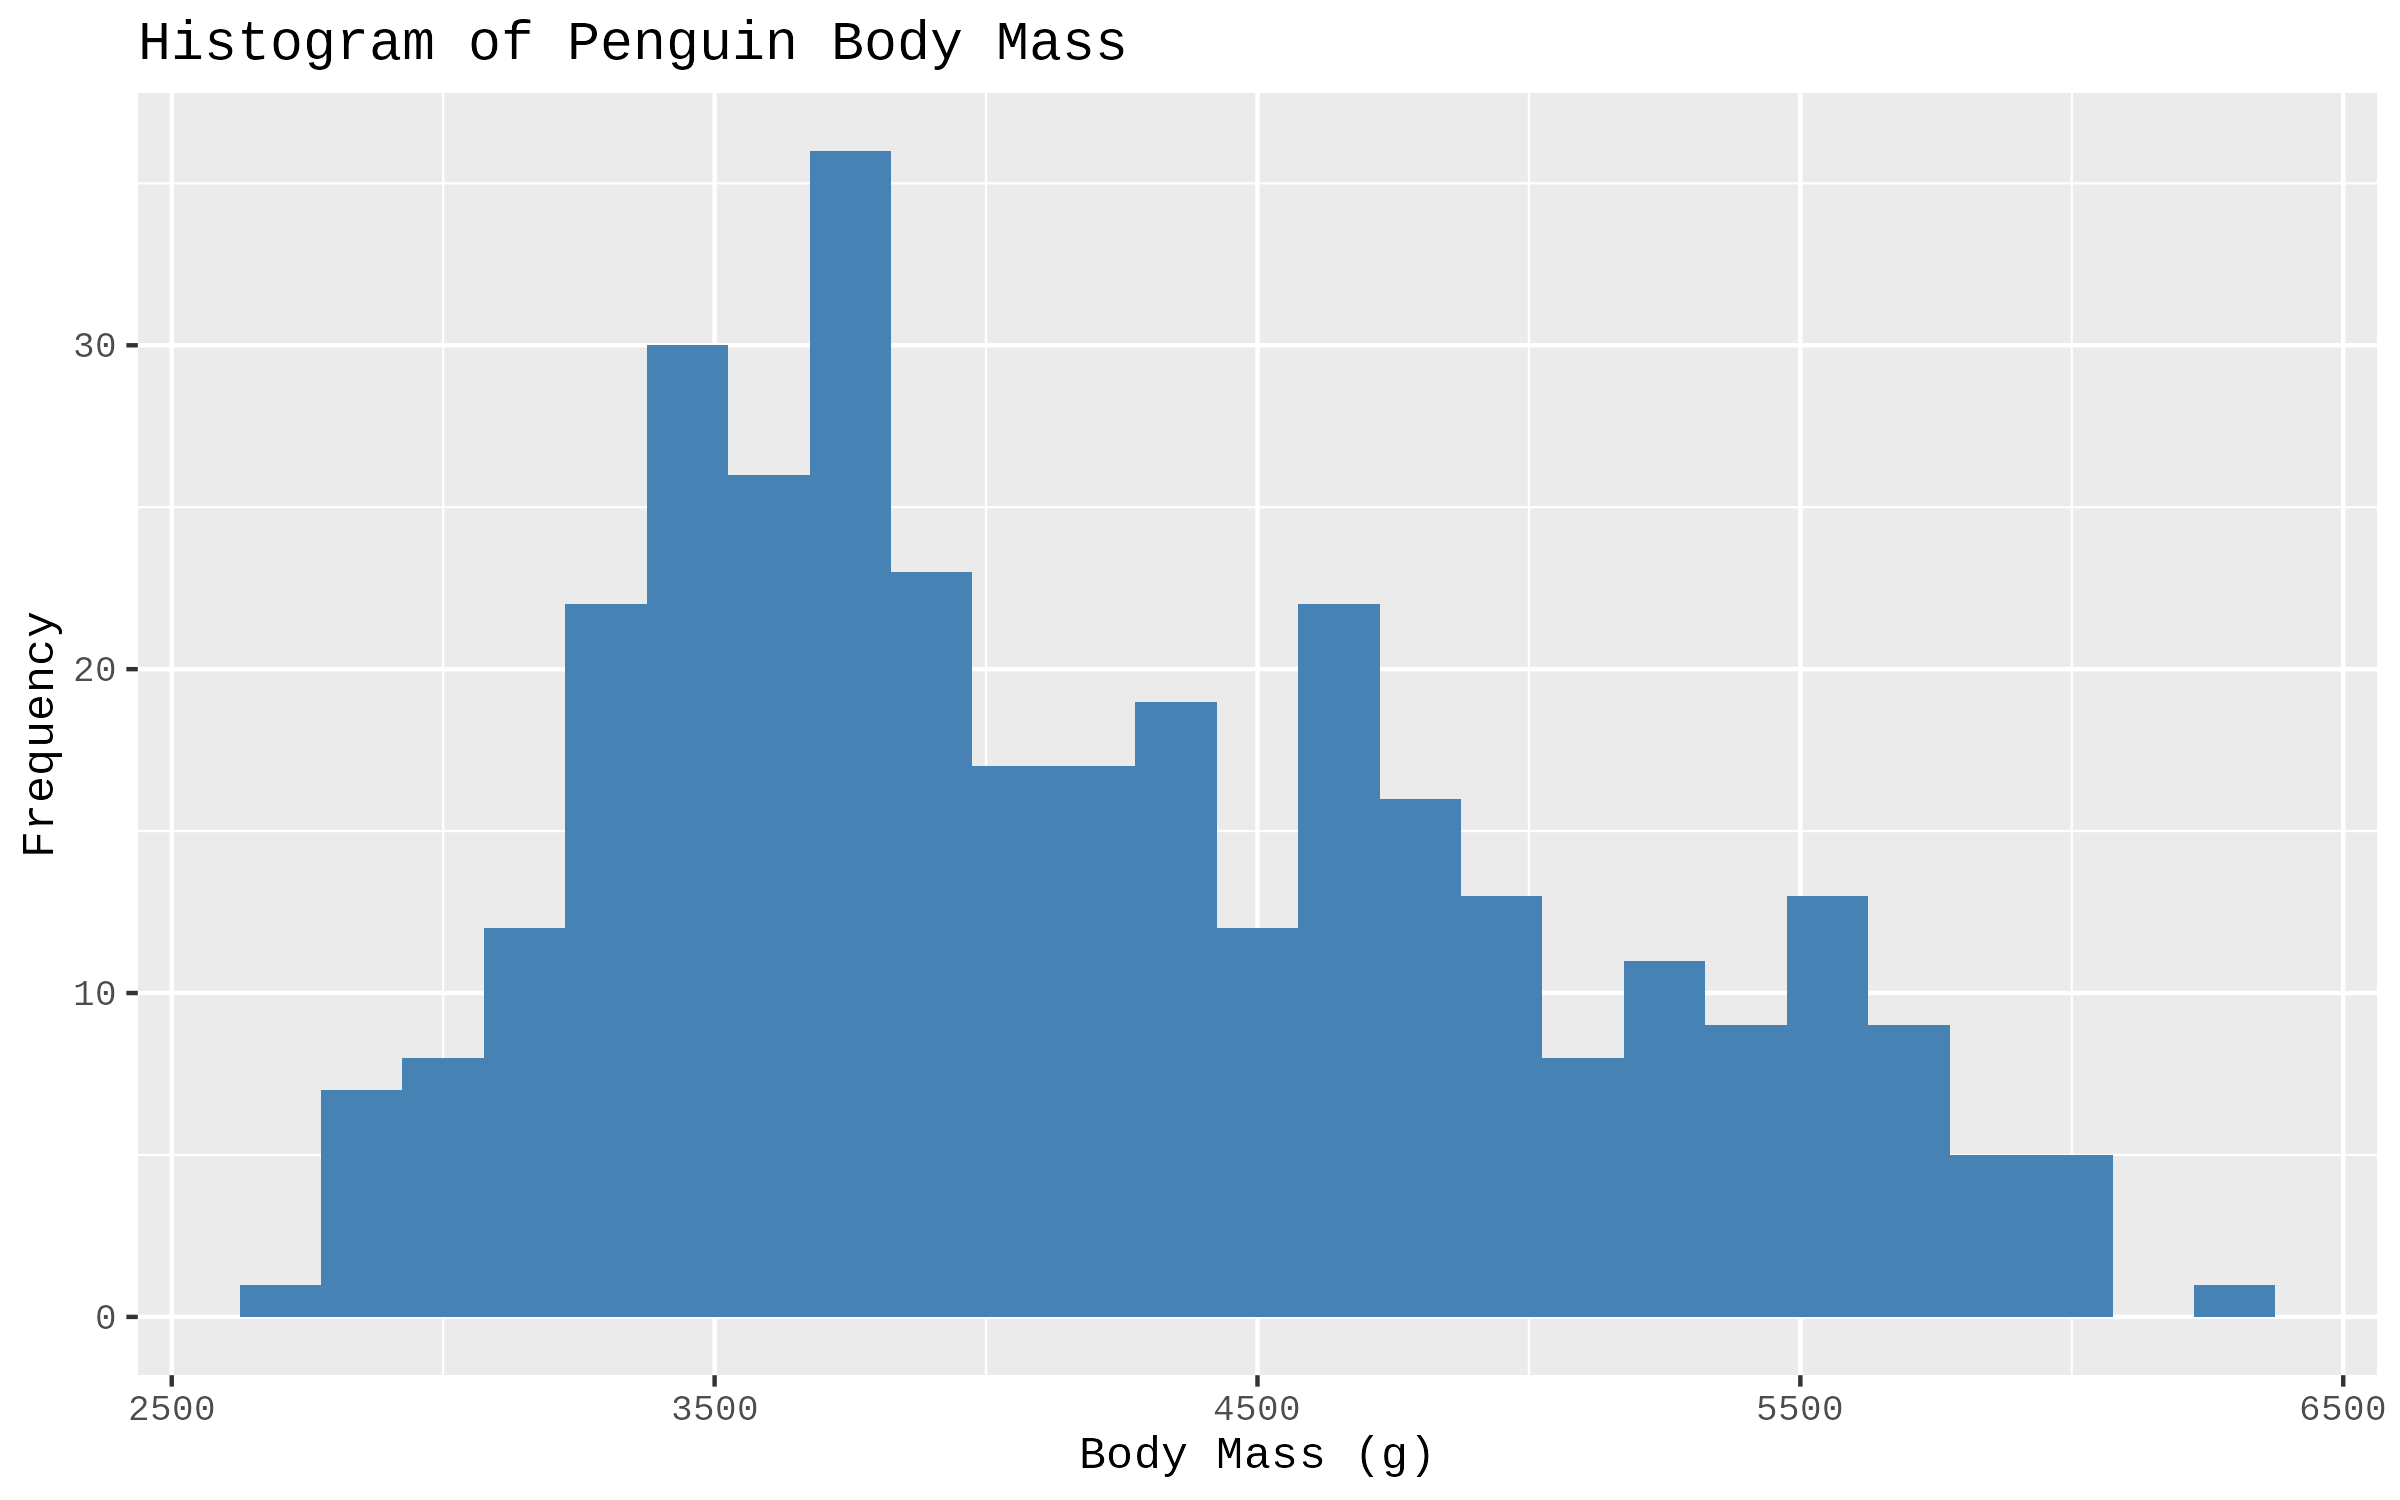


02_species_body_mass_boxplot.png


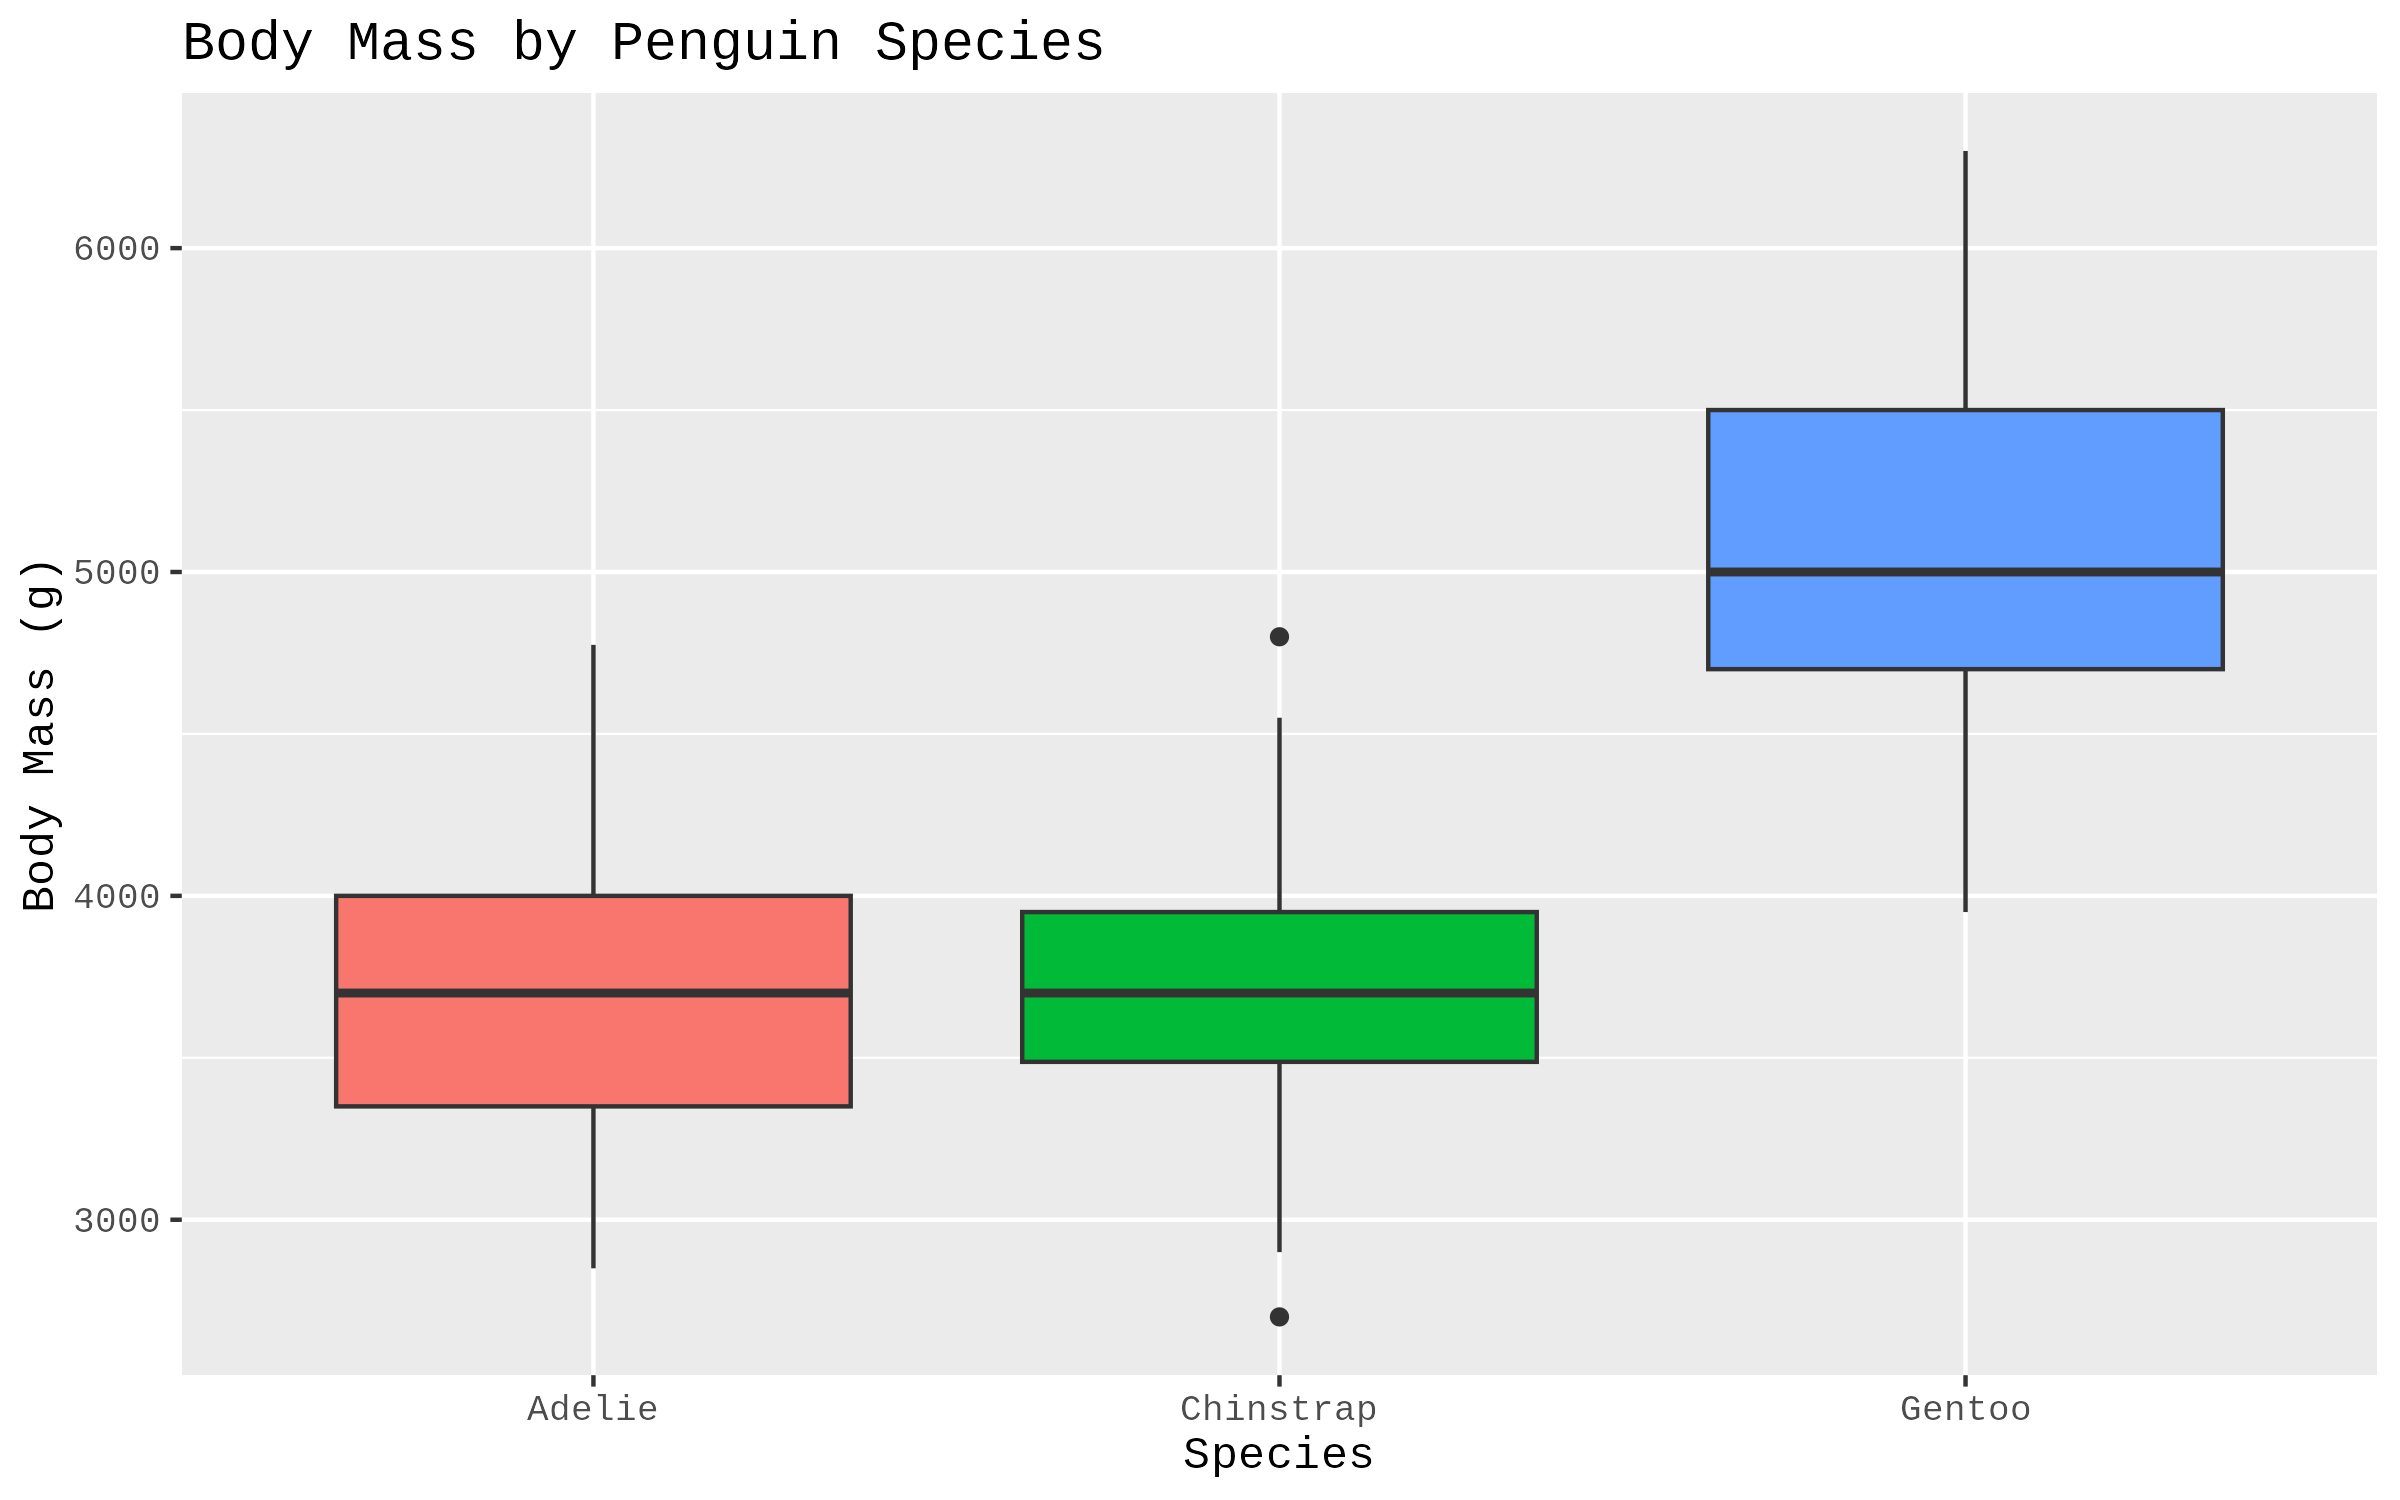


03_body_mass_density.png


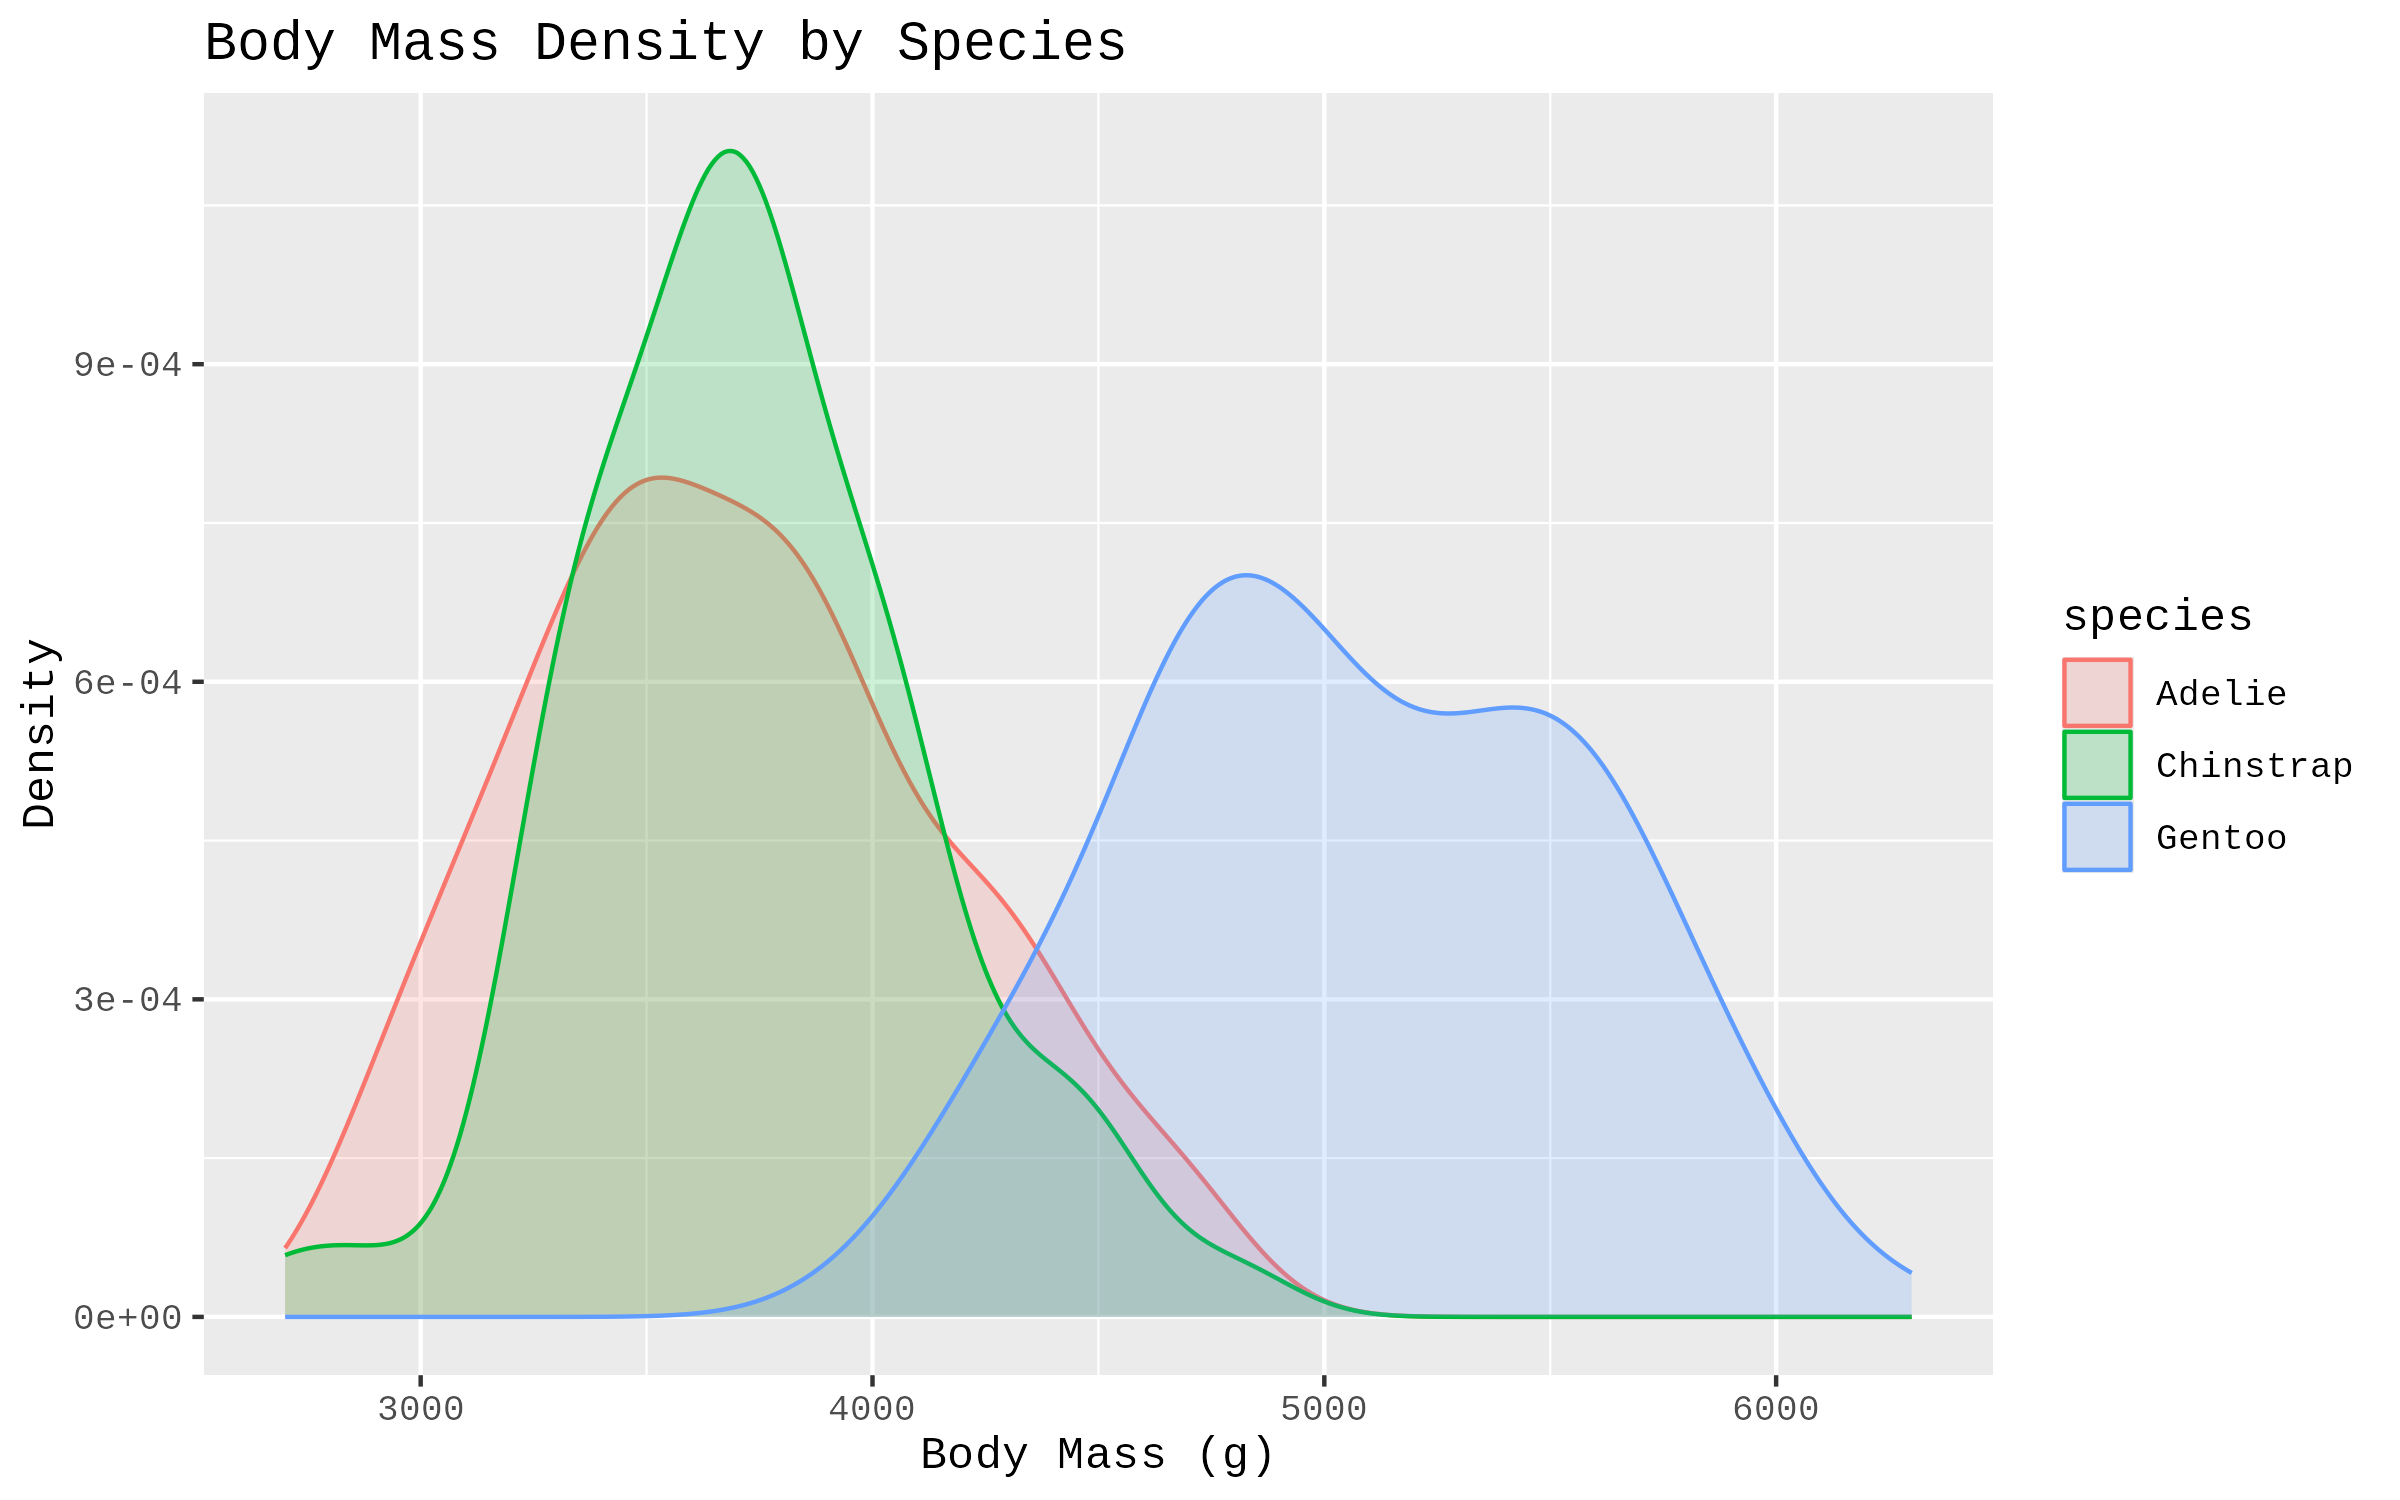


04_sex_body_mass_boxplot.png


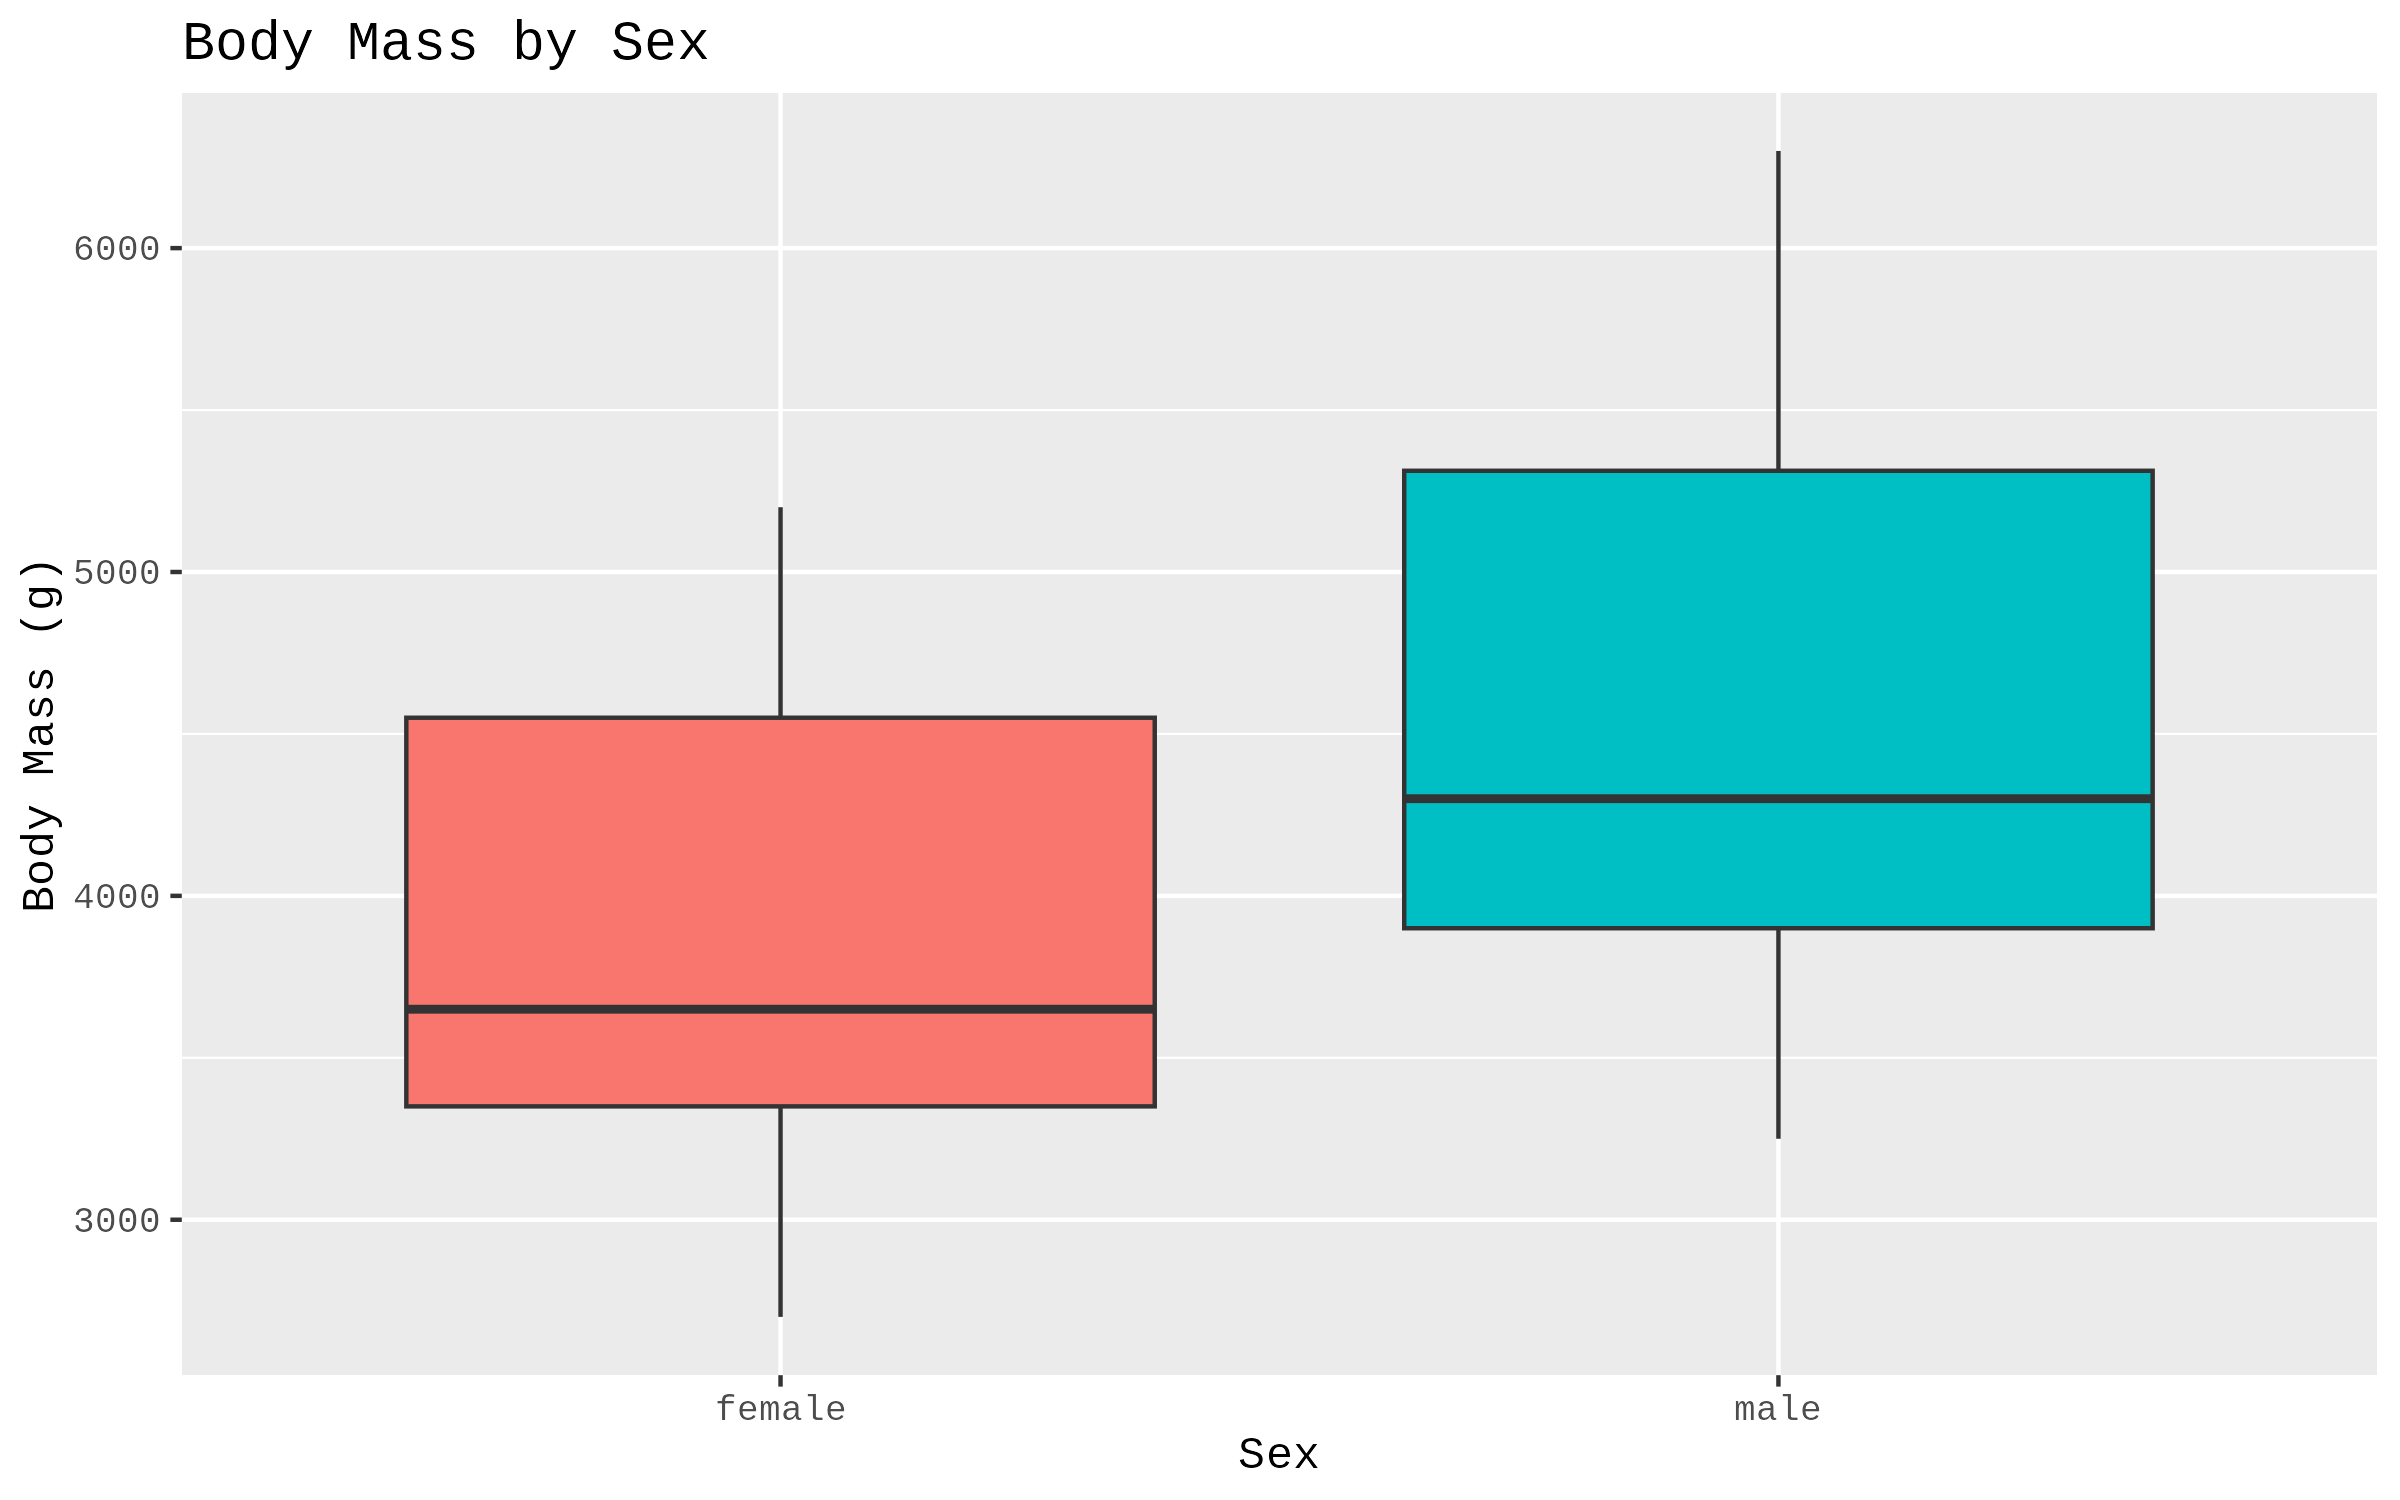


05_QQ_male.png


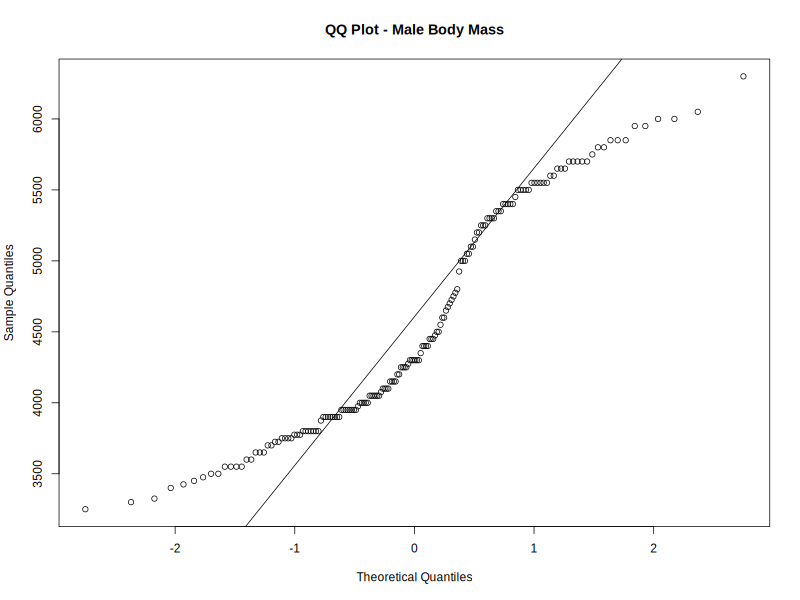


06_QQ_female.png


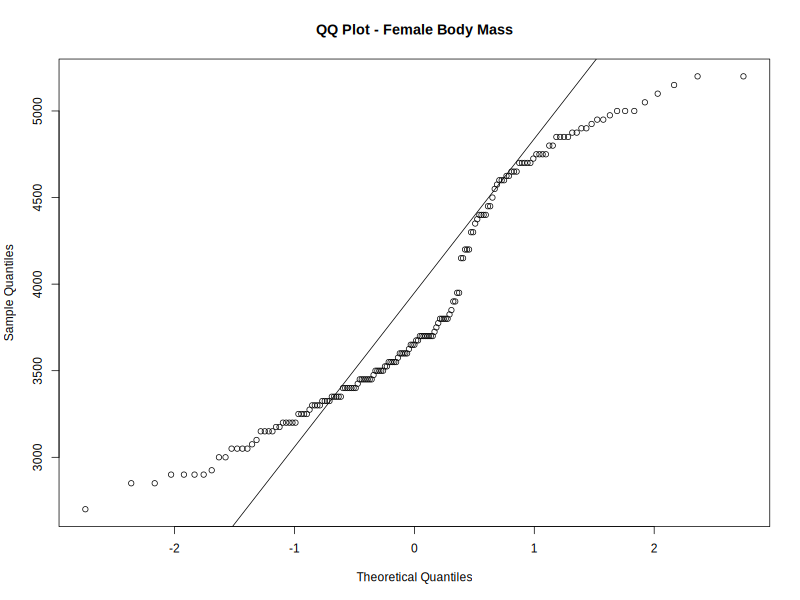


07_ANOVA_QQ_plot.png


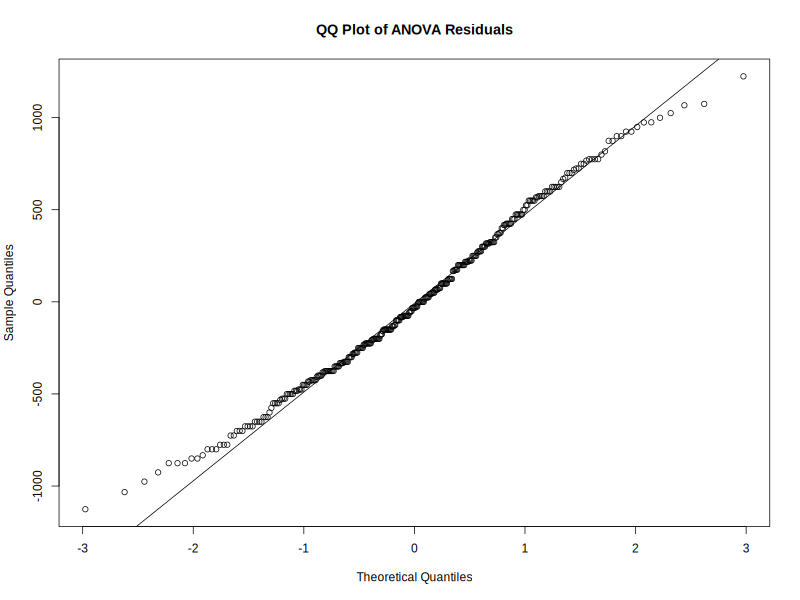


08_species_sex_interaction.png


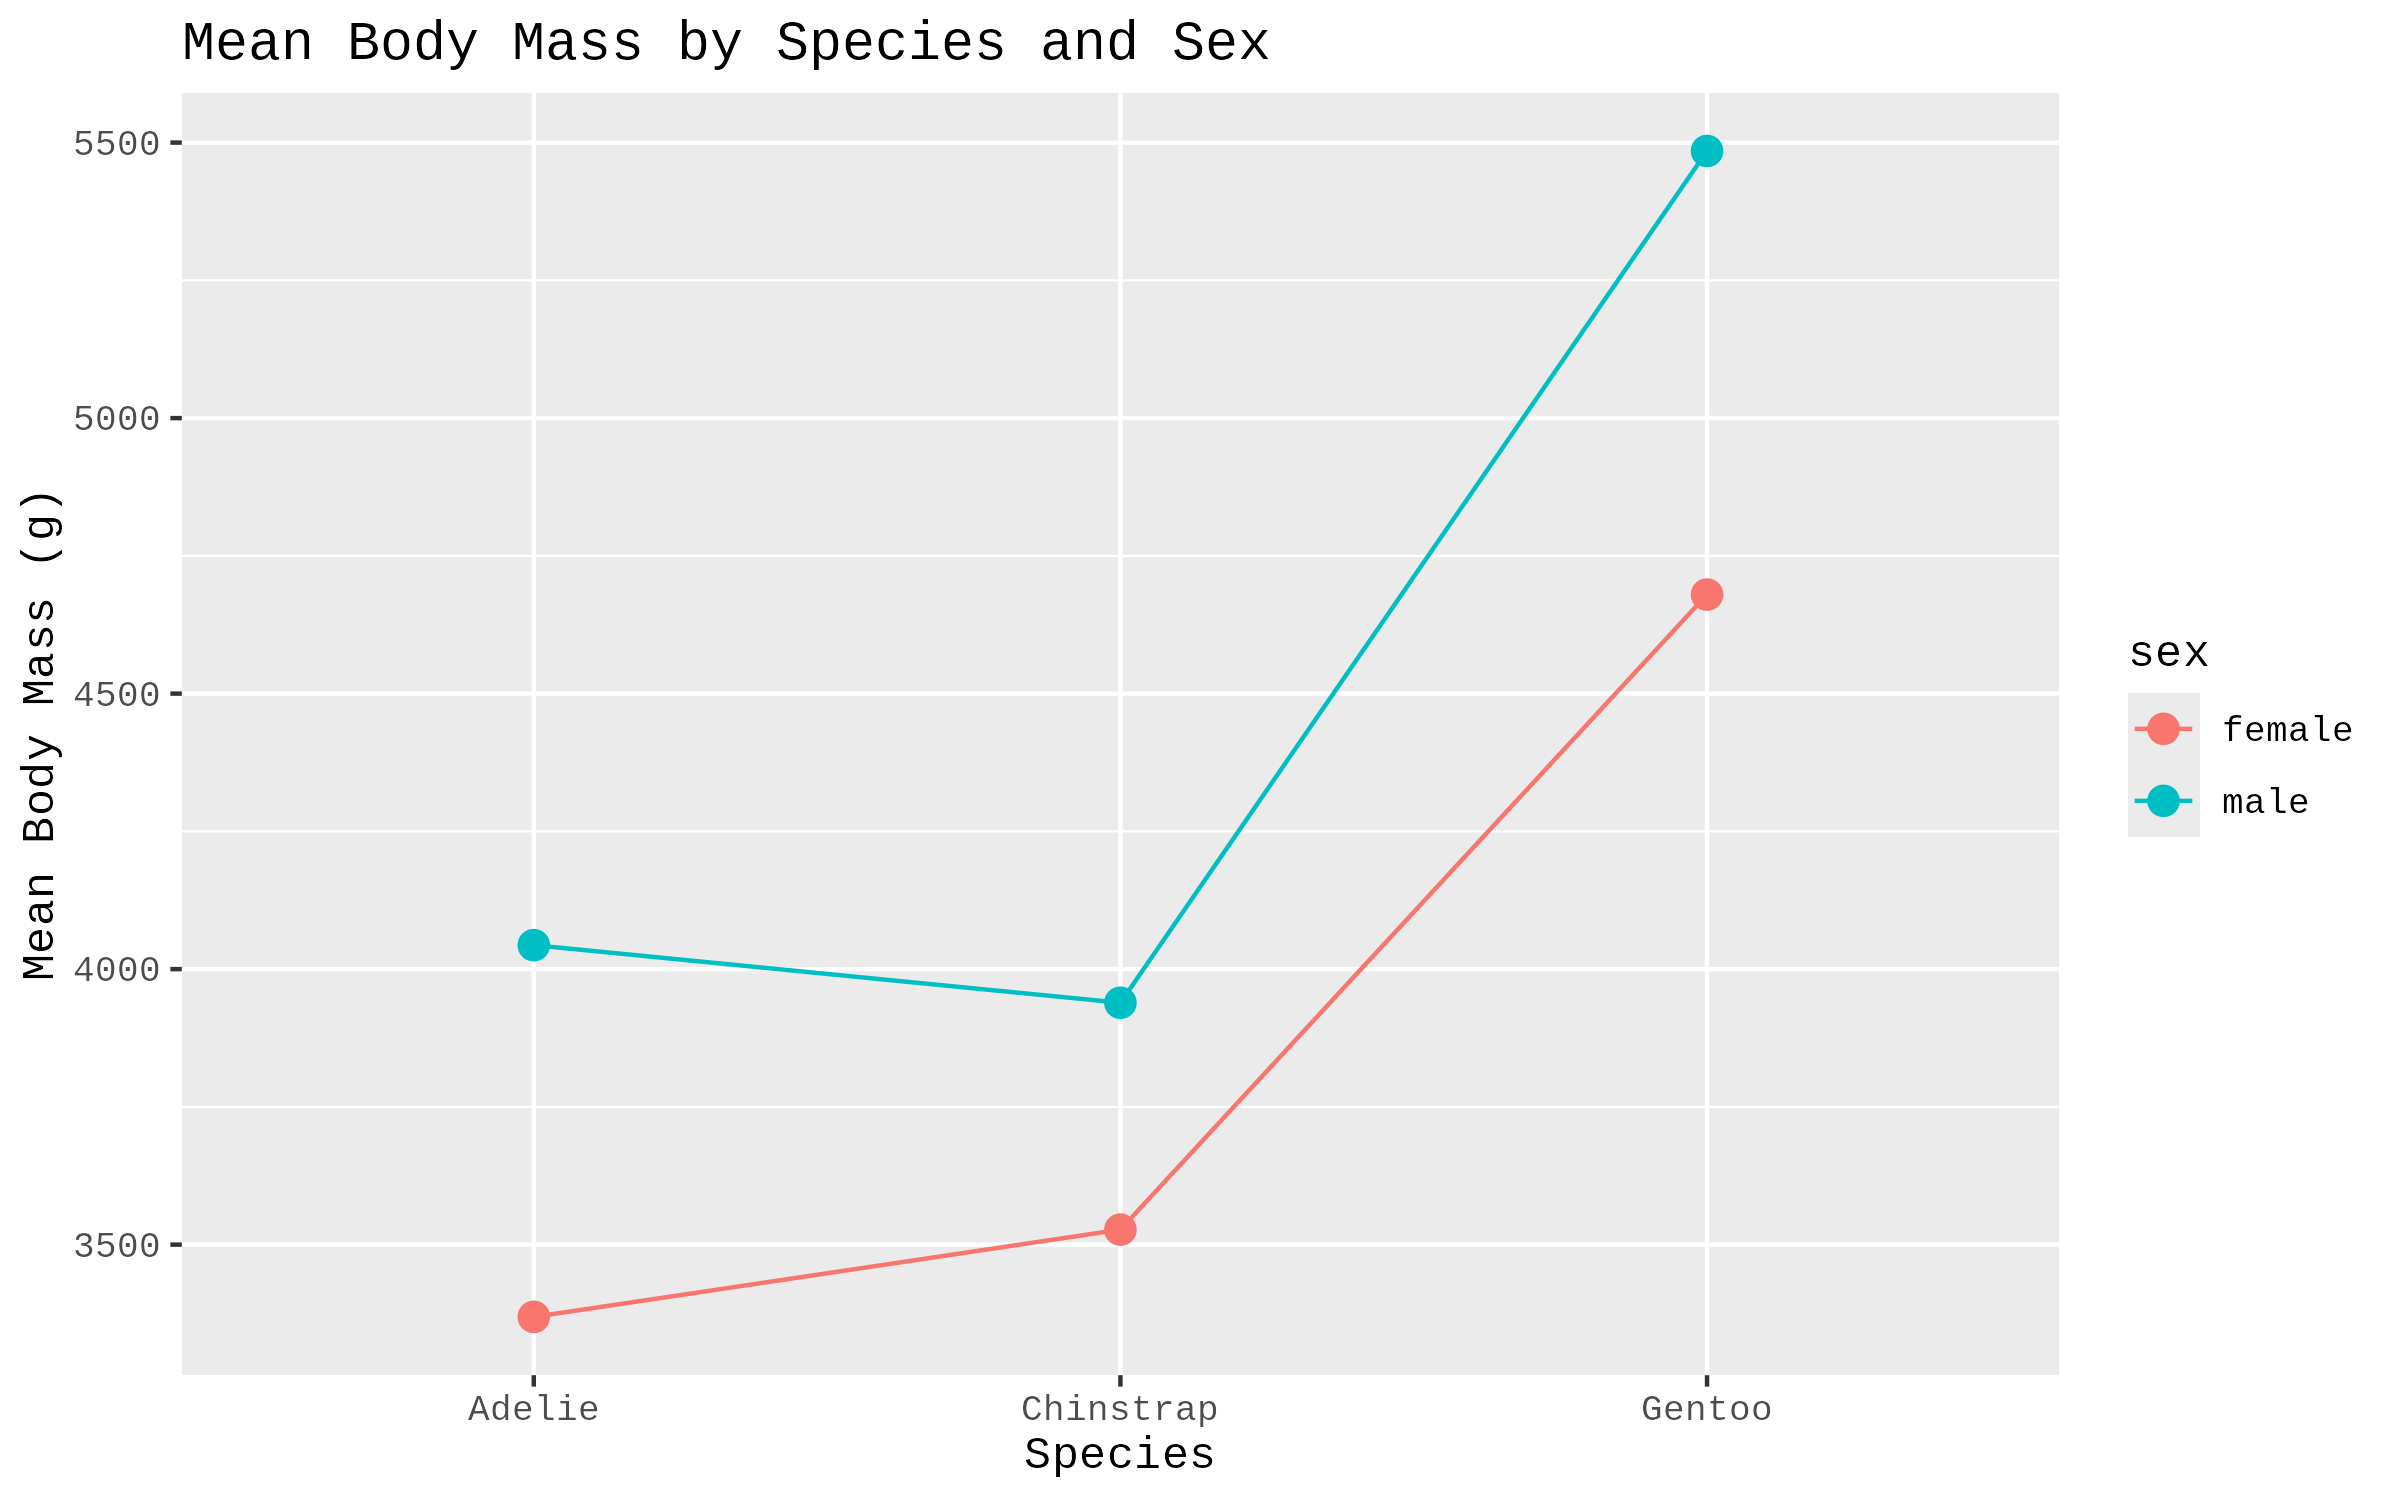


09_flipper_length_by_species.png


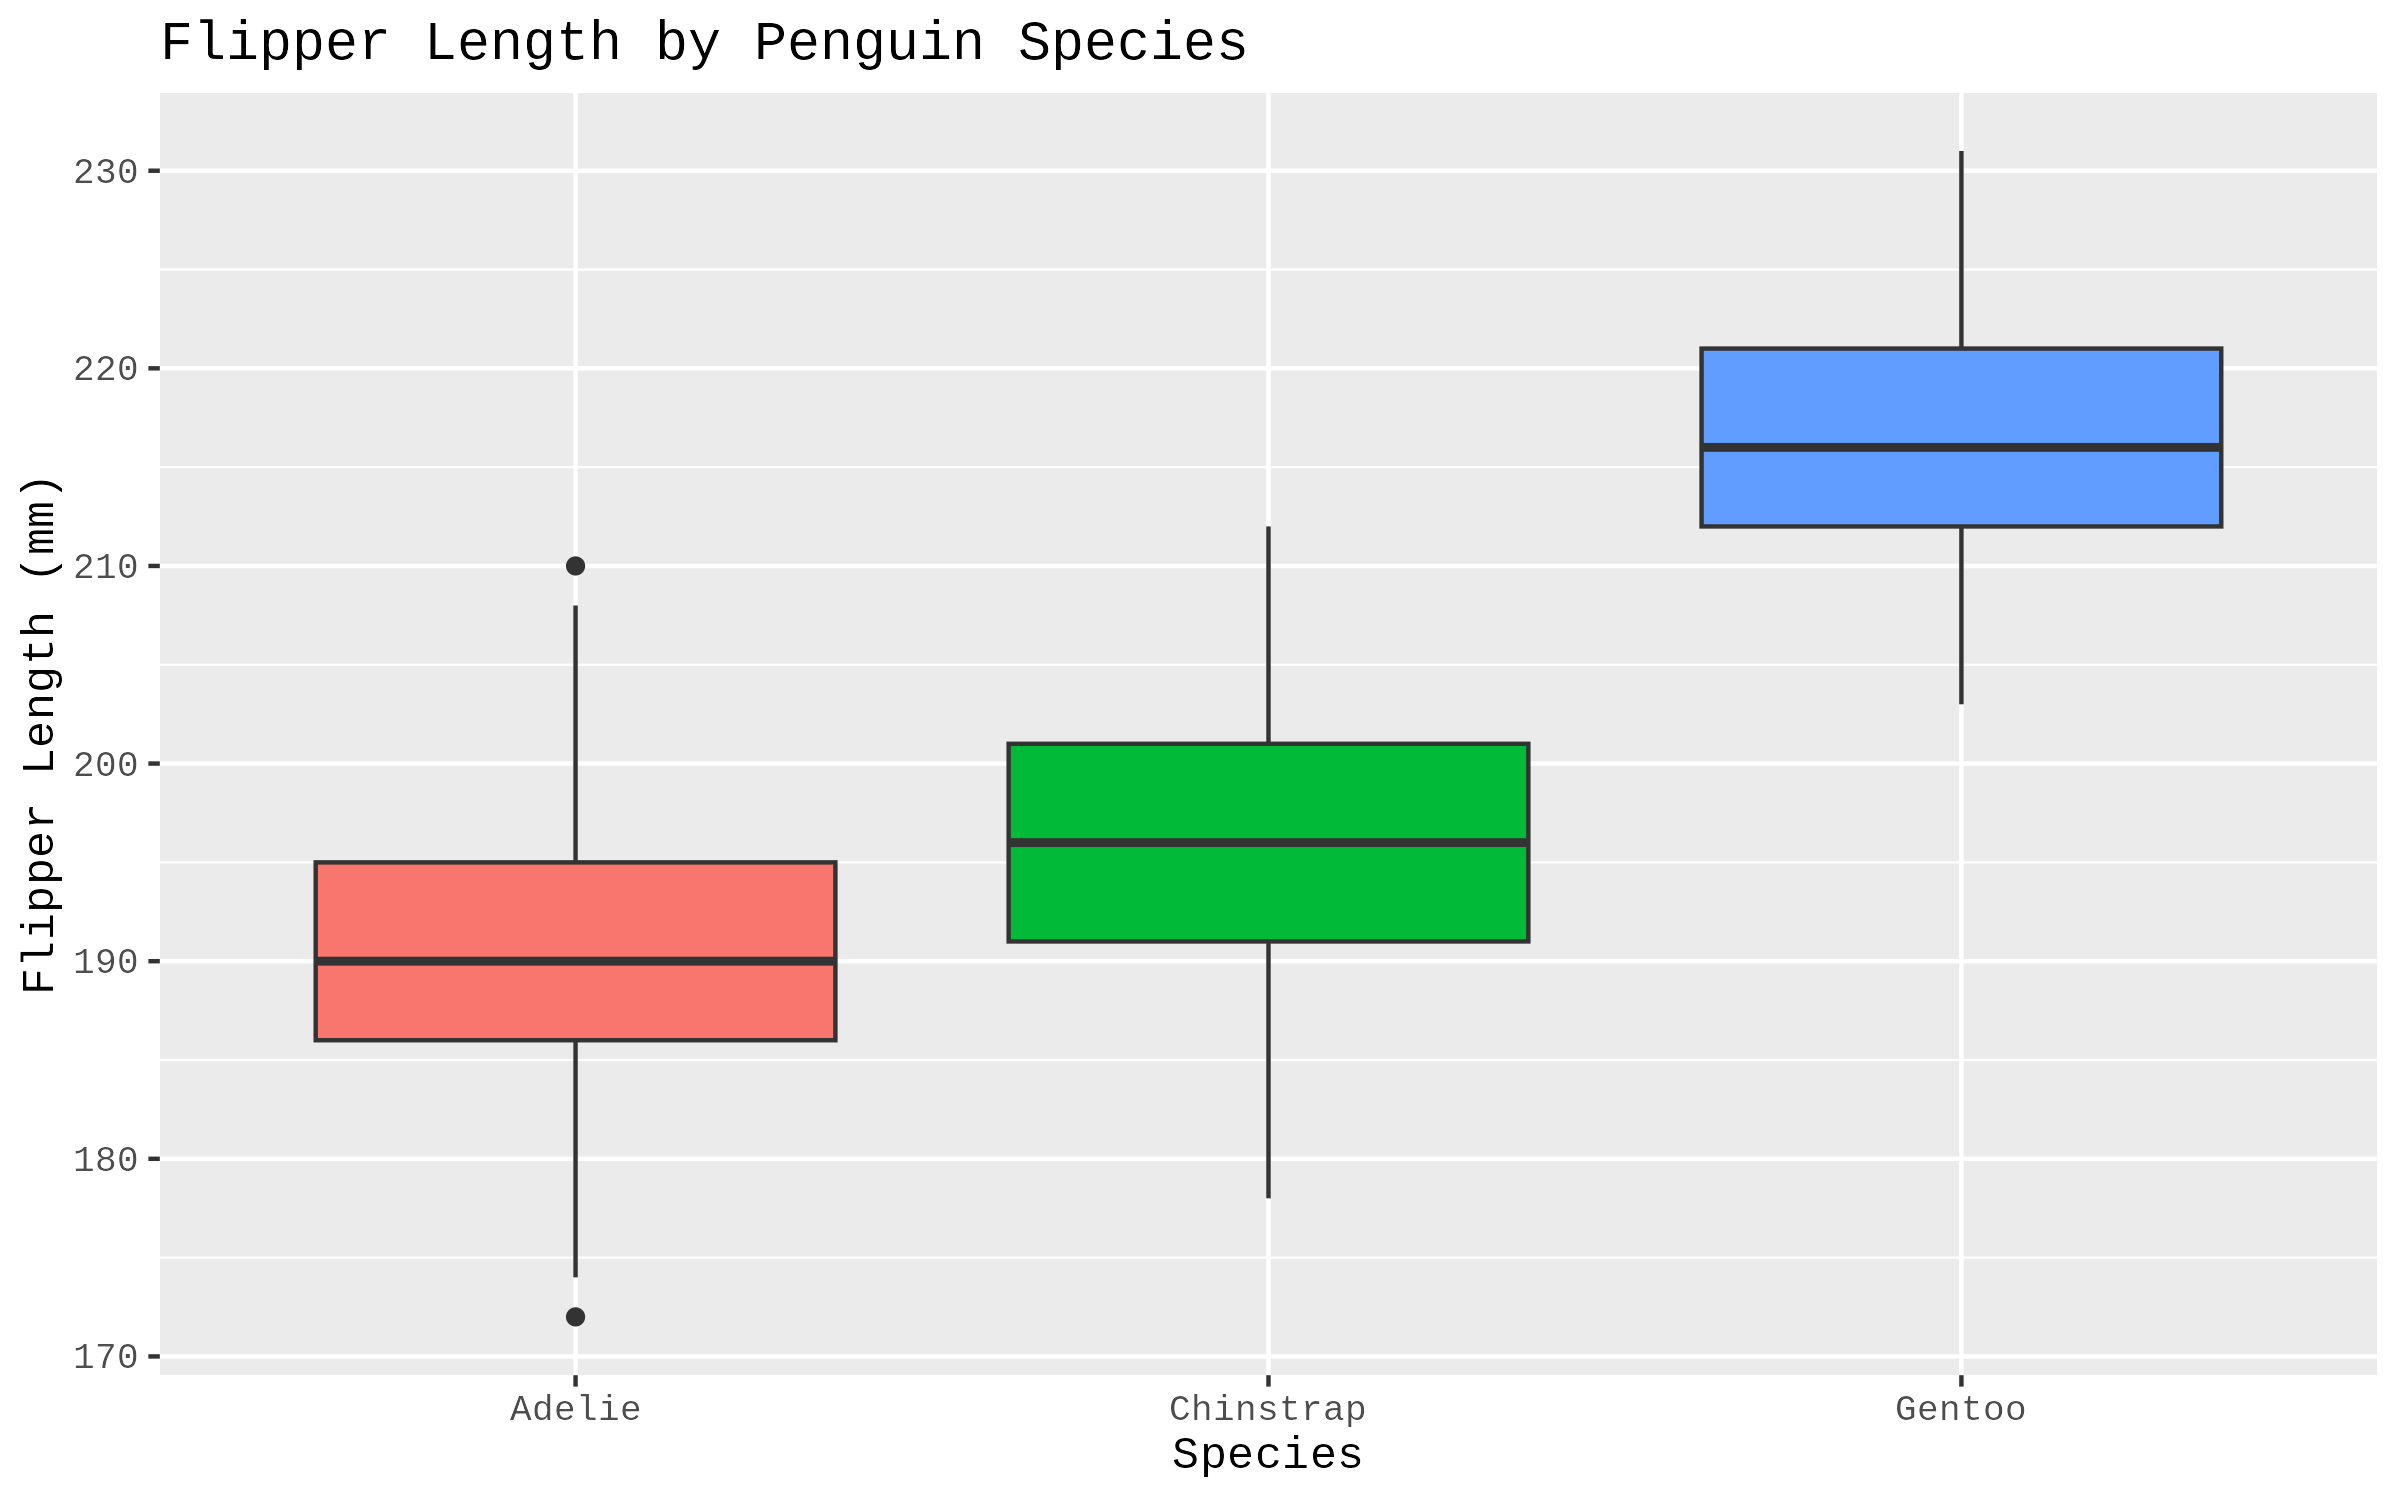


10_species_mean_comparison.png


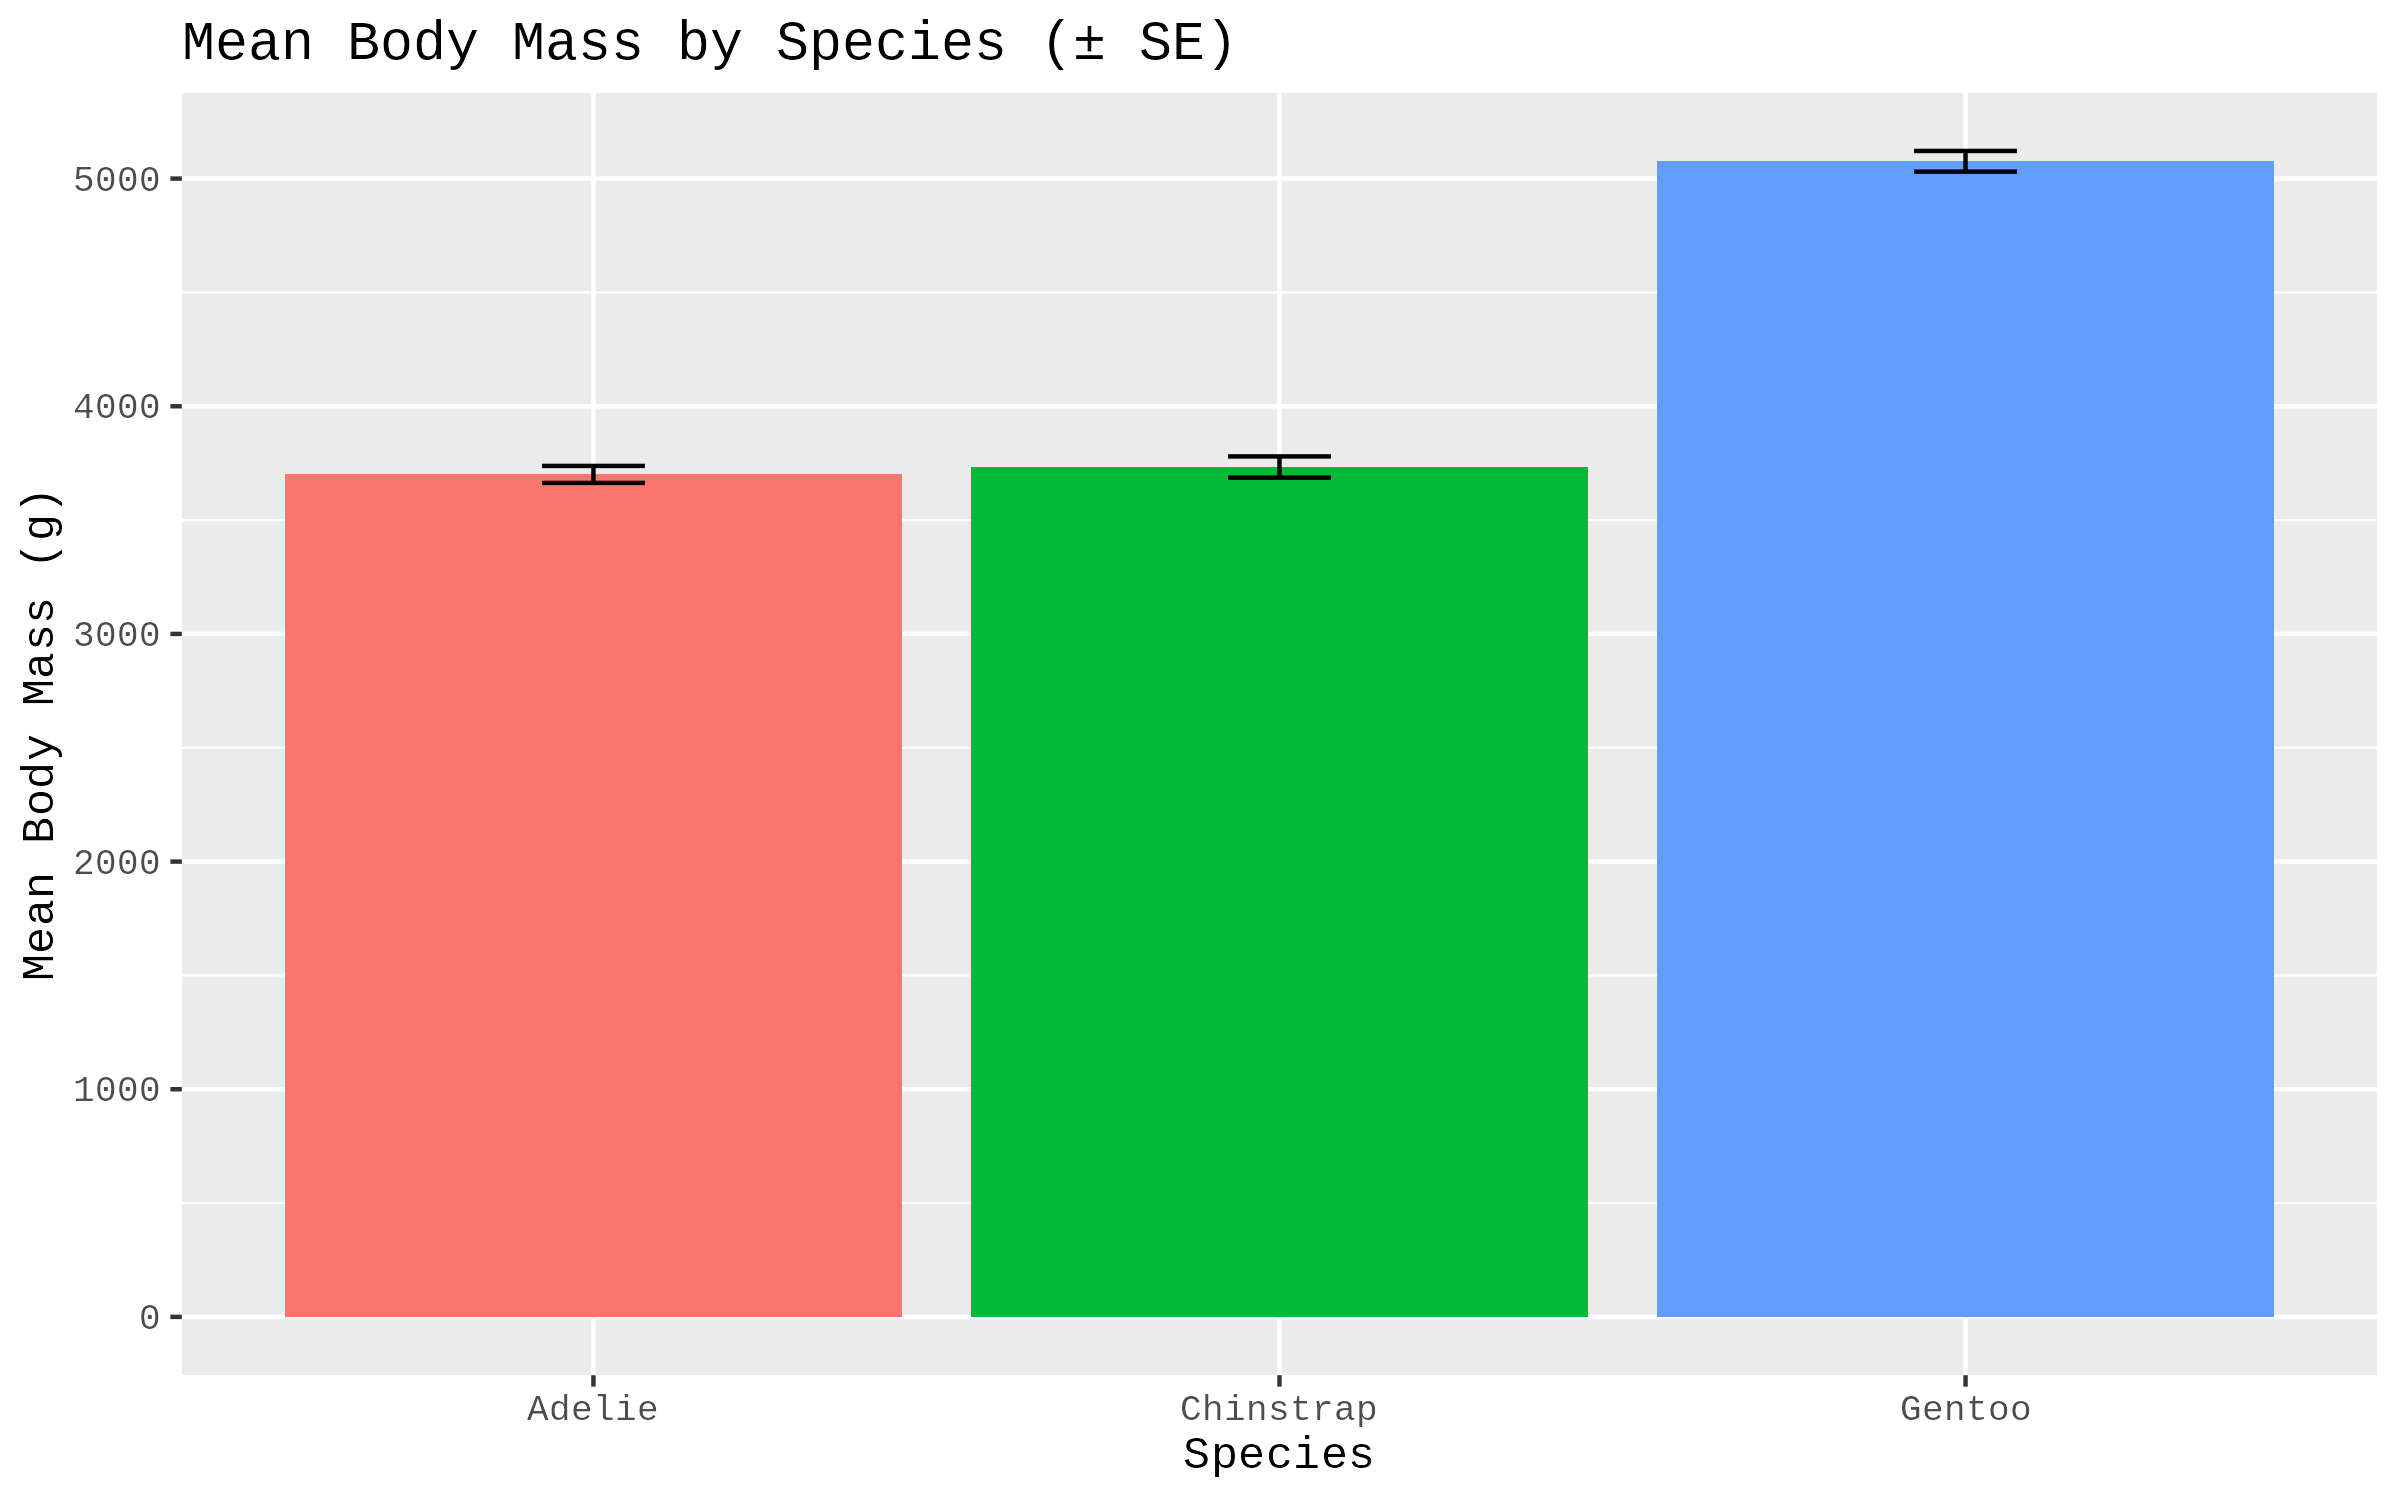

In [7]:
# CELL 7 — Display all visualizations
from IPython.display import Image, display
plots=["01_body_mass_histogram.png","02_species_body_mass_boxplot.png","03_body_mass_density.png",
"04_sex_body_mass_boxplot.png","05_QQ_male.png","06_QQ_female.png","07_ANOVA_QQ_plot.png",
"08_species_sex_interaction.png","09_flipper_length_by_species.png","10_species_mean_comparison.png"]
for p in plots:
    print("\n"+p)
    display(Image("/content/"+p))

In [8]:
# CELL 8 — Create final submission ZIP
import os, shutil
out="/content/LAB_PS6_FINAL_DELIVERABLES"
os.makedirs(out,exist_ok=True)
files=["lab_ps6_palmer_penguins.R","descriptive_statistics.csv","sex_shapiro_tests.csv",
"t_test_results.csv","one_way_anova_table.csv","species_shapiro_tests.csv","levene_test.csv",
"tukey_hsd_results.csv","kruskal_wallis_results.csv","two_way_anova_table.csv",
"flipper_one_way_anova.csv","flipper_kruskal_wallis.csv","statistical_interpretation.txt",
"validation_summary.csv","README.txt","01_body_mass_histogram.png","02_species_body_mass_boxplot.png",
"03_body_mass_density.png","04_sex_body_mass_boxplot.png","05_QQ_male.png","06_QQ_female.png",
"07_ANOVA_QQ_plot.png","08_species_sex_interaction.png","09_flipper_length_by_species.png",
"10_species_mean_comparison.png"]
for f in files:
    if os.path.exists("/content/"+f): shutil.copy("/content/"+f,out+"/"+f)
zip_path=shutil.make_archive("/content/LAB_PS6_FINAL_DELIVERABLES","zip",out)
print("✓ Final ZIP:",zip_path)

✓ Final ZIP: /content/LAB_PS6_FINAL_DELIVERABLES.zip


In [9]:
# CELL 9 — Download final ZIP
from google.colab import files
files.download("/content/LAB_PS6_FINAL_DELIVERABLES.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>